IMPORTING ALL ESSENTIAL LIBRARIES...

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, HuberRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



loading the dataset and splitting into train and test data

In [ ]:
df = pd.read_excel("decline_curve_dataset.xlsx")
X = df.drop(columns=["Production Rate (bbl/day)"])
y = df["Production Rate (bbl/day)"]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



Exploratory data analysis

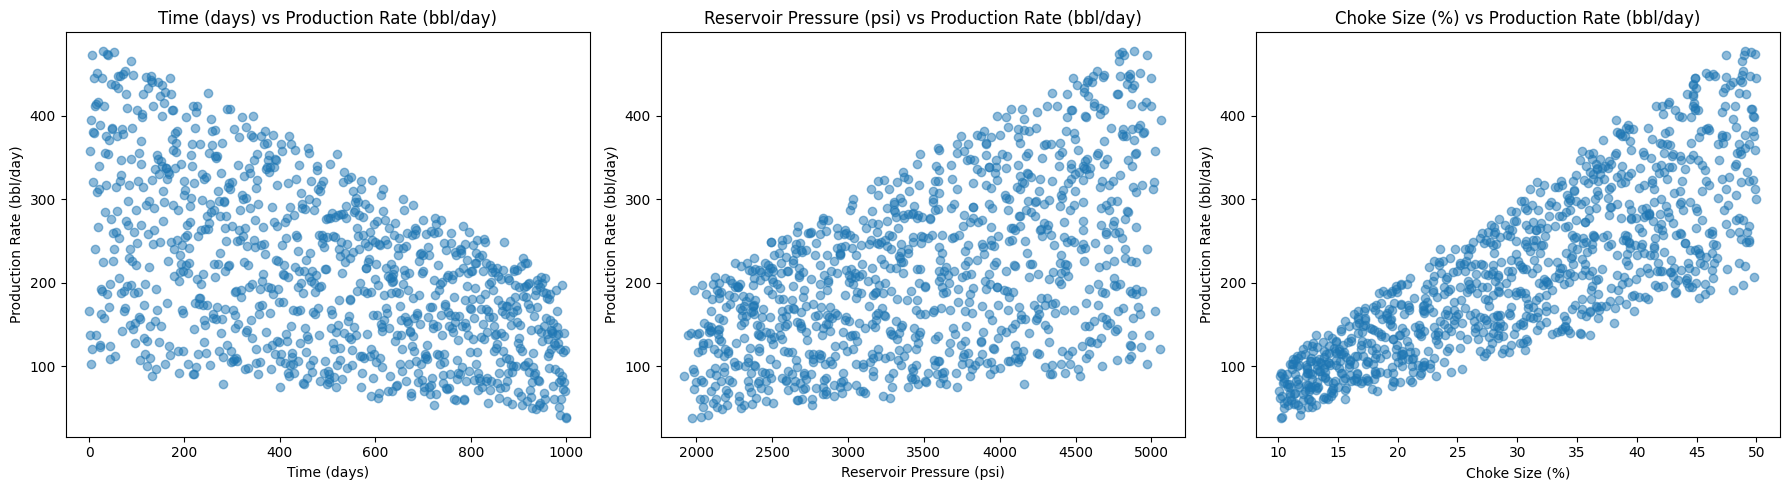

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("decline_curve_dataset.xlsx")
features = ["Time (days)", "Reservoir Pressure (psi)", "Choke Size (%)"]
target = "Production Rate (bbl/day)"

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for ax, feature in zip(axs, features):
    ax.scatter(df[feature], df[target], alpha=0.5)
    ax.set_xlabel(feature)
    ax.set_ylabel(target)
    ax.set_title(f"{feature} vs {target}")
plt.tight_layout()
plt.show()


distribution of dataset.

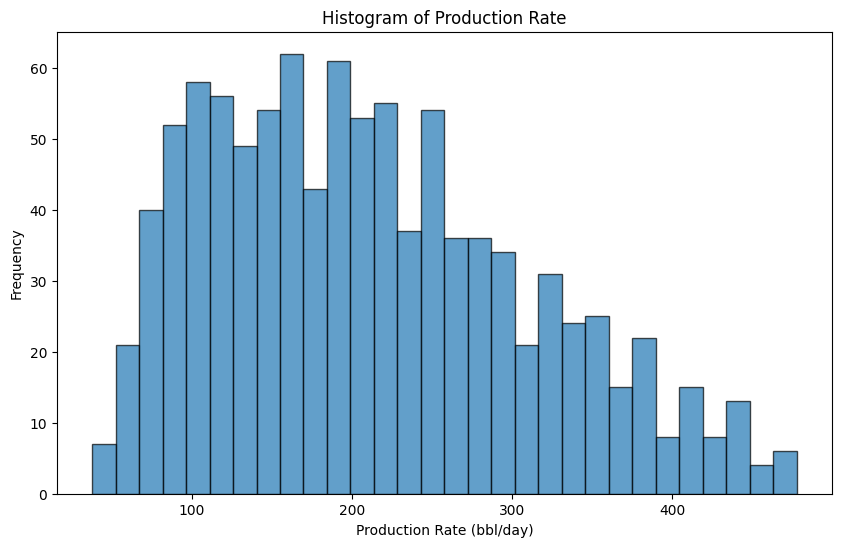

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("decline_curve_dataset.xlsx")

plt.figure(figsize=(10, 6))
plt.hist(df["Production Rate (bbl/day)"], bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Production Rate (bbl/day)")
plt.ylabel("Frequency")
plt.title("Histogram of Production Rate")
plt.show()


Calling all models like linear, huber, xgboost...

In [ ]:
linear_model = LinearRegression()
huber_model = HuberRegressor()
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=100)



training our model

In [ ]:
linear_model.fit(X_train, y_train)
huber_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

predicting the model with test dataset

In [ ]:
y_pred_linear = linear_model.predict(X_test)
y_pred_huber = huber_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)



evaluation metrices for evaluation of each model using function

In [ ]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2



model performance below.

In [ ]:
print("Linear Regression:", evaluate_model(y_test, y_pred_linear))
print("Huber Regression:", evaluate_model(y_test, y_pred_huber))
print("XGBoost:", evaluate_model(y_test, y_pred_xgb))


Linear Regression: (16.02603454534012, 436.9683572535832, 20.90378810774696, 0.9535756501033926)
Huber Regression: (15.95734289541929, 432.2261842178112, 20.790050125428056, 0.9540794675918411)
XGBoost: (5.951998602652625, 56.872927936812815, 7.541414186796321, 0.9939577118975439)


Linear Regression Conclusion:
Linear Regression offers a simple, interpretable approach that effectively captures the overall trend in the data. However, its simplicity may limit its ability to model more complex, non-linear relationships.


Huber Regression Conclusion:
Huber Regression provides robustness against outliers while maintaining interpretability, making it effective for noisy datasets. It strikes a balance between simplicity and stability in predictions.

XGBoost Conclusion:
XGBoost excels at capturing both linear and non-linear patterns, leading to superior predictive accuracy. Its ensemble nature handles complex interactions well, though it comes with increased computational demands.

plotting the performance using the matplotlib

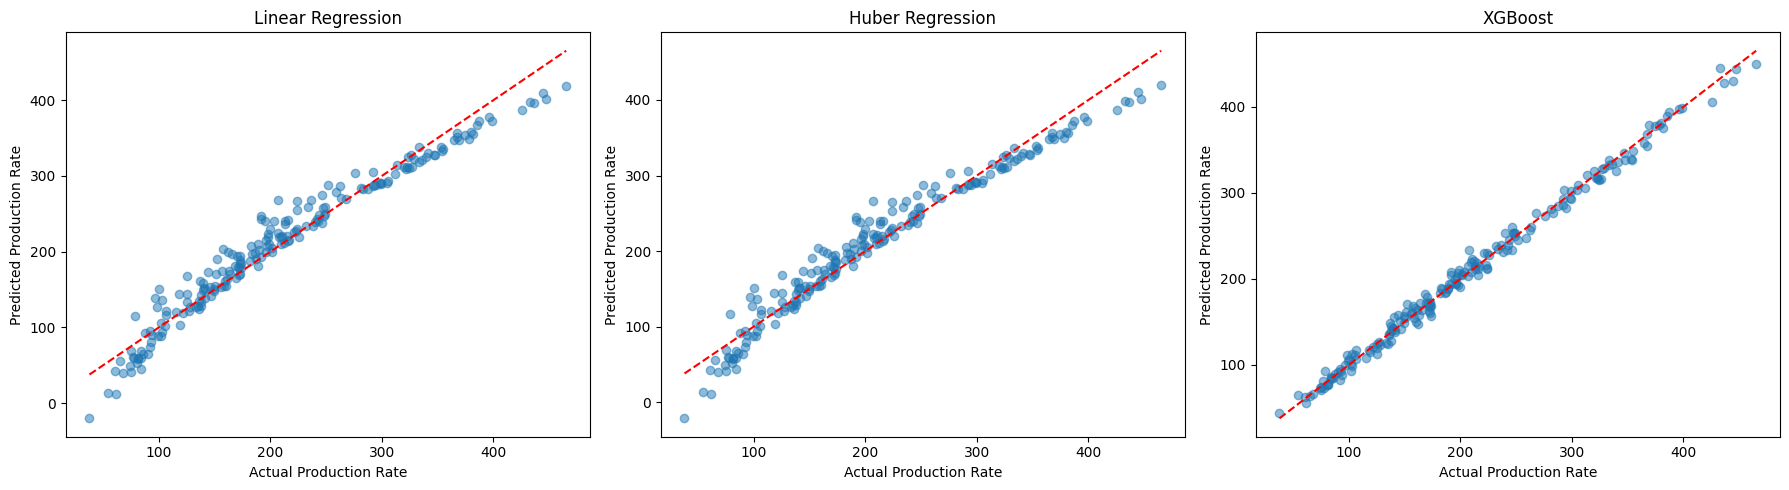

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))
models = [("Linear Regression", y_pred_linear), ("Huber Regression", y_pred_huber), ("XGBoost", y_pred_xgb)]
for i, (name, y_pred) in enumerate(models, 1):
    plt.subplot(1, 3, i)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual Production Rate")
    plt.ylabel("Predicted Production Rate")
    plt.title(name)
plt.tight_layout()
plt.show()


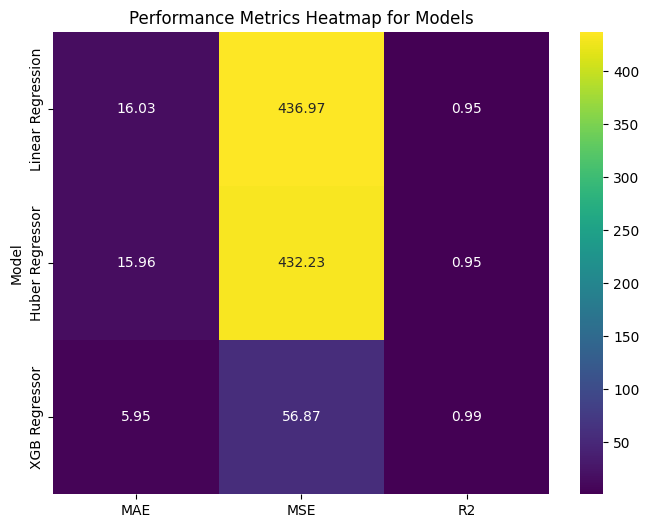

In [ ]:
models = {"Linear Regression": linear_model, "Huber Regressor": huber_model, "XGB Regressor": xgb_model}
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metrics = {'Model': [], 'MAE': [], 'MSE': [], 'R2': []}
for name, model in models.items():
    y_pred = model.predict(X_test)
    metrics['Model'].append(name)
    metrics['MAE'].append(mean_absolute_error(y_test, y_pred))
    metrics['MSE'].append(mean_squared_error(y_test, y_pred))
    metrics['R2'].append(r2_score(y_test, y_pred))

df_metrics = pd.DataFrame(metrics).set_index('Model')
plt.figure(figsize=(8,6))
sns.heatmap(df_metrics, annot=True, cmap='viridis', fmt=".2f")
plt.title("Performance Metrics Heatmap for Models")
plt.show()

I am going to do the same task by ANN also. but there are some limitations of using ANN here.

Here we are using tensorflow and sequential model to train our model using ANN but it is not  useful and learn the noise using because of such small dataset of 1000 datapoinnts but in our industry only such small dataset are available ,  hence most of the times , we avoid using ANN.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Training the model using two hidden layers.

In [ ]:
model_ann = Sequential()
model_ann.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model_ann.add(Dense(32, activation='relu'))
model_ann.add(Dense(1))



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


compiling our model using 50 epochs and using adam optimizer...

In [ ]:
model_ann.compile(optimizer='adam', loss='mean_squared_error')
model_ann.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

y_pred_ann = model_ann.predict(X_test)



Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 54039.9531 - val_loss: 57604.4883
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 53431.7383 - val_loss: 56805.4258
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 51871.5156 - val_loss: 55349.3359
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 52649.5703 - val_loss: 52828.0391
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 46212.3789 - val_loss: 48843.4922
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45700.9805 - val_loss: 43241.7461
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 39903.3984 - val_loss: 36224.0352
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 31896.6562 - val_loss: 28501.6875
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25762.3848 - val_loss: 20846.4258
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 16896.0430 - val_loss: 14401.2998
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11930.7109 - val_l

Evaluation metrices

In [ ]:
mae_ann = mean_absolute_error(y_test, y_pred_ann)
mse_ann = mean_squared_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mse_ann)
r2_ann = r2_score(y_test, y_pred_ann)



In [ ]:
print("ANN Performance:")
print("MAE:", mae_ann)
print("MSE:", mse_ann)
print("RMSE:", rmse_ann)
print("R²:", r2_ann)

ANN Performance:
MAE: 19.043733270987715
MSE: 700.4655207331027
RMSE: 26.46630916340816
R²: 0.9255812099772902


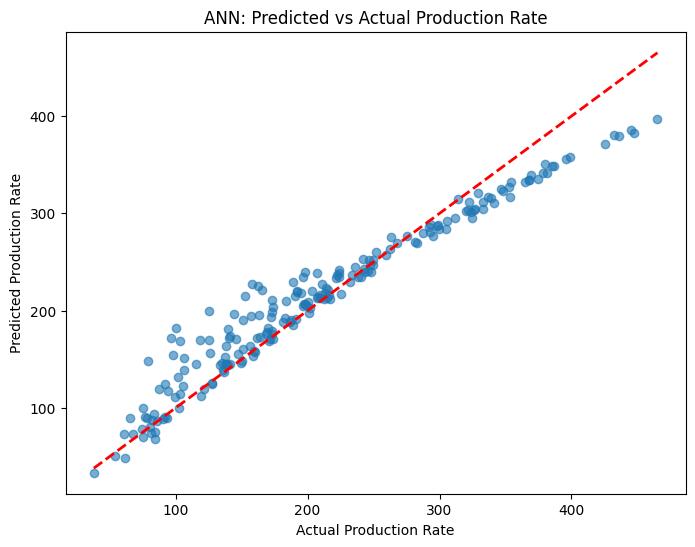

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_ann, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Production Rate")
plt.ylabel("Predicted Production Rate")
plt.title("ANN: Predicted vs Actual Production Rate")
plt.show()
